# Neural Network Basics with Affon
This notebook combines the core feed-forward and recurrent examples into one walkthrough. 
It covers linear regression, logistic regression, custom object modules, and simple RNNs using the current `affon:nn` surface.


In [1]:
import {
  tensor,
  parameter,
  module,
  randn,
  linspace,
  matmul,
  add,
  sigmoid,
  clear_grad,
  grad,
  sgd,
} from 'affon:compute'
import type { Tensor } from 'affon:compute'
import nn from 'affon:nn'
import { figure, title, xlabel, ylabel, plot, scatter, savefig, show } from 'affon:plot'


## Helpers

In [2]:
function asColumn(values: number[]): number[][] {
  return values.map(value => [value])
}

## Linear Regression (nn.Sequential)
Fits **y = 3x + 2** with noise using a single `nn.Linear` layer.


## Generate Data

**y = 3x + 2 + noise**

In [3]:
const xData = asColumn(linspace(0, 10, 100).to_array() as number[])
const noise = randn([xData.length, 1]).to_array() as number[][]
const yData = xData.map((row, i) => [3 * row[0] + 2 + noise[i][0] * 0.8])

const X = tensor(xData)
const y = tensor(yData)


## Model & Training

epoch 0: loss = 58.57331466674805
epoch 10: loss = 15.377104759216309
epoch 20: loss = 4.922397613525391
epoch 30: loss = 2.3871326446533203
epoch 40: loss = 1.7674505710601807
epoch 50: loss = 1.6111630201339722
epoch 60: loss = 1.5670230388641357
epoch 70: loss = 1.5500718355178833
epoch 80: loss = 1.5397590398788452
epoch 90: loss = 1.5311132669448853


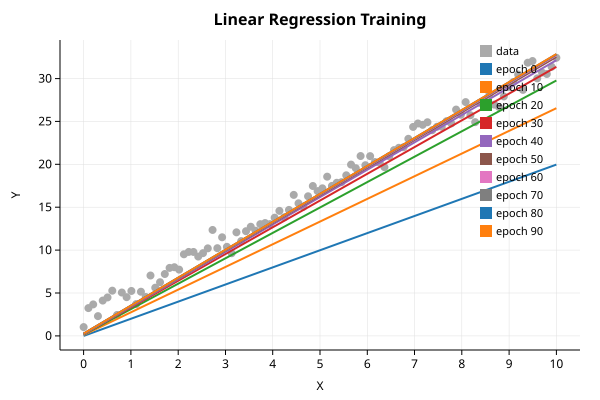

In [4]:
figure({ width: 600, height: 400 })
title('Linear Regression Training')
xlabel('X')
ylabel('Y')
scatter(X, y, { color: '#aaaaaa', label: 'data' })

const model = nn.Sequential(
  nn.Linear(1, 1)
)

const params = model.parameters
const step = sgd({ lr: 0.001 })
const criterion = nn.MSELoss()

const epochs = 100

for (let epoch = 0; epoch < epochs; epoch++) {
  clear_grad(params)
  const pred = model(X)
  const loss = criterion(pred, y)
  grad(loss, params)
  step(params)

  if (epoch % 10 === 0) {
    plot(X, pred, { label: `epoch ${epoch}` })
    console.log(`epoch ${epoch}: loss =`, loss.item())
  }
}

show()


## Linear Regression (Custom Module)
Implements `LinearRegression` manually with W and b parameters, equivalent to a PyTorch-style module.


## Custom LinearRegression Module

Forward: `X @ W + b`

In [5]:
const LinearRegression = (in_features: number, out_features: number) => {
  const W = parameter([in_features, out_features]).randn()
  const b = parameter([1, out_features]).randn()

  return module({ W, b }, (state, X: Tensor) => {
    return add(matmul(X, state.W), state.b)
  })
}


## Generate Data

**y = 3x + 2 + noise**

In [6]:
const xData = asColumn(linspace(0, 10, 100).to_array() as number[])
const noise = randn([xData.length, 1]).to_array() as number[][]
const yData = xData.map((row, i) => [3 * row[0] + 2 + noise[i][0] * 2])

const X = tensor(xData)
const y = tensor(yData)


## Model & Training

Initial parameters:
  W: [1×1 Tensor, dtype=f32]
            0
  ┌            ┐
0 │  0.817324  │
  └            ┘

  b: [1×1 Tensor, dtype=f32]
             0
  ┌             ┐
0 │  -0.579213  │
  └             ┘

epoch 0: loss = 210.44036865234375
epoch 10: loss = 54.65437316894531
epoch 20: loss = 16.961692810058594
epoch 30: loss = 7.832993030548096
epoch 40: loss = 5.613360404968262
epoch 50: loss = 5.064972400665283
epoch 60: loss = 4.920932769775391
epoch 70: loss = 4.874804496765137
epoch 80: loss = 4.852474212646484
epoch 90: loss = 4.836009979248047
Final parameters:
  W: [1×1 Tensor, dtype=f32]
            0
  ┌            ┐
0 │  3.218957  │
  └            ┘

  b: [1×1 Tensor, dtype=f32]
             0
  ┌             ┐
0 │  -0.093572  │
  └             ┘



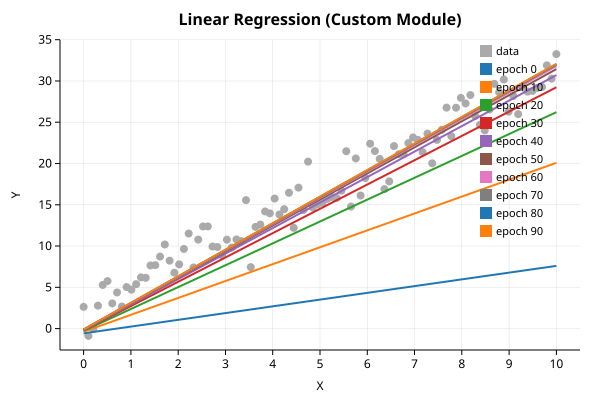

In [7]:
figure({ width: 600, height: 400 })
title('Linear Regression (Custom Module)')
xlabel('X')
ylabel('Y')
scatter(X, y, { color: '#aaaaaa', label: 'data' })

const model = LinearRegression(1, 1)

console.log('Initial parameters:')
console.log('  W:', model.W)
console.log('  b:', model.b)

const params = model.parameters
const step = sgd({ lr: 0.001 })
const criterion = nn.MSELoss()

const epochs = 100
const sample = 10

for (let epoch = 0; epoch < epochs; epoch++) {
  clear_grad(params)
  const pred = model(X)
  const loss = criterion(pred, y)
  grad(loss, params)
  step(params)

  if (epoch % sample === 0) {
    plot(X, pred, { label: `epoch ${epoch}` })
    console.log(`epoch ${epoch}: loss =`, loss.item())
  }
}

console.log('Final parameters:')
console.log('  W:', model.W)
console.log('  b:', model.b)

show()


## Logistic Regression (nn.Sequential)
Binary classification: predicts 0/1 based on a single feature. Uses sigmoid activation.


## Data

In [8]:
const X = tensor([[1], [5], [10], [10], [25], [50], [70], [75], [100]])
const Y = tensor([[0], [0], [0], [0], [0], [1], [1], [1], [1]])


## Model: Linear + Sigmoid

In [9]:
const model = nn.Sequential(
  nn.Linear(1, 1)
)

const params = model.parameters
const step = sgd({ lr: 0.004 })
const criterion = nn.BCEWithLogitsLoss()


## Training

In [10]:
const epochs = 2000
const sample = 200

const losses: number[] = []
let lastLogits = model(X)

for (let epoch = 0; epoch < epochs; epoch++) {
  clear_grad(params)
  const logits = model(X)
  const loss = criterion(logits, Y)
  grad(loss, params)
  step(params)

  losses.push(loss.item())
  lastLogits = logits

  if (epoch % sample === 0) {
    console.log('epoch', epoch, 'loss =', loss.item())
  }
}


epoch 0 loss = 32.63375473022461
epoch 200 loss = 0.48477253317832947
epoch 400 loss = 0.4398999810218811
epoch 600 loss = 0.4015616178512573
epoch 800 loss = 0.36869102716445923
epoch 1000 loss = 0.34037846326828003
epoch 1200 loss = 0.3158629238605499
epoch 1400 loss = 0.2945154011249542
epoch 1600 loss = 0.2758195102214813
epoch 1800 loss = 0.2593521475791931


## Plot: Predictions vs Targets

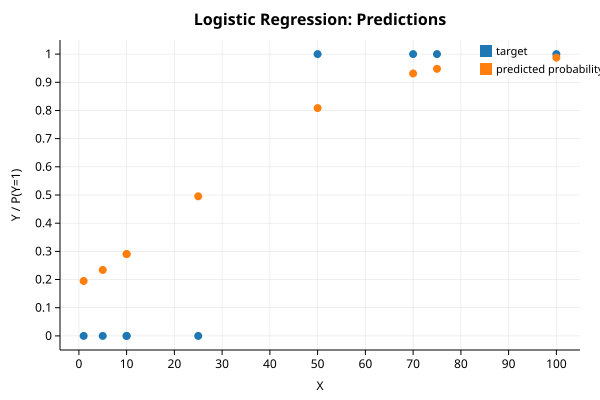

In [11]:
figure({ width: 600, height: 400 })
title('Logistic Regression: Predictions')
xlabel('X')
ylabel('Y / P(Y=1)')
scatter(X, Y, { color: '#1f77b4', label: 'target' })
scatter(X, sigmoid(lastLogits), { color: '#ff7f0e', label: 'predicted probability' })
show()


## Plot: Loss Curve

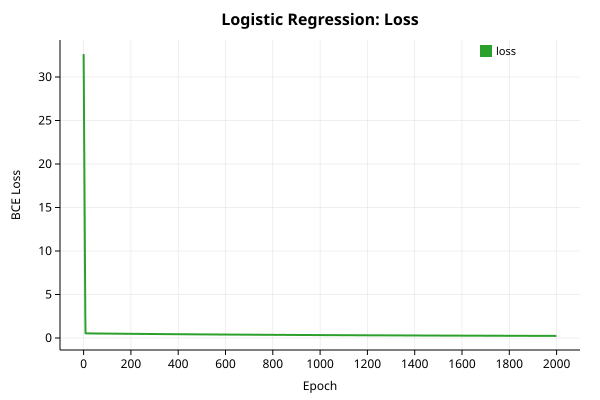

In [12]:
figure({ width: 600, height: 400 })
title('Logistic Regression: Loss')
xlabel('Epoch')
ylabel('BCE Loss')
plot(losses, { label: 'loss', color: '#2ca02c' })
show()

## Logistic Regression (Custom Module)
Uses `compute.module(...)` as the single module primitive, while `nn` supplies layers and parameter registration.


## Field Access On Object Modules

Forward: `sigmoid(X @ W + b)`

Object modules are the default path. This variant keeps `W` and `b` as owned fields on the returned module, so `model.W` and `model.b` stay accessible.


In [13]:
const LogisticRegression = (in_features: number, out_features: number) => {
  const W = parameter([in_features, out_features]).randn()
  const b = parameter([1, out_features]).randn()

  return module({ W, b }, (state, X: Tensor): Tensor => {
    return add(matmul(X, state.W), state.b)
  })
}


## Data

In [14]:
const X = tensor([[1], [5], [10], [10], [25], [50], [70], [75], [100]])
const Y = tensor([[0], [0], [0], [0], [0], [1], [1], [1], [1]])


## Model & Optimizer

In [15]:
const model = LogisticRegression(1, 1)

console.log('Initial parameters:')
console.log('  W:', model.W)
console.log('  b:', model.b)

const params = model.parameters
const step = sgd({ lr: 0.004 })
const criterion = nn.BCEWithLogitsLoss()


Initial parameters:
  W: [1×1 Tensor, dtype=f32]
           0
  ┌           ┐
0 │  0.43544  │
  └           ┘

  b: [1×1 Tensor, dtype=f32]
             0
  ┌             ┐
0 │  -1.640548  │
  └             ┘



## Training

In [16]:
const epochs = 2000
const sample = 200

const losses: number[] = []
let lastLogits = model(X)

for (let epoch = 0; epoch < epochs; epoch++) {
  clear_grad(params)
  const logits = model(X)
  const loss = criterion(logits, Y)
  grad(loss, params)
  step(params)

  losses.push(loss.item())
  lastLogits = logits

  if (epoch % sample === 0) {
    console.log('epoch', epoch, 'loss =', loss.item())
  }
}

console.log('Final parameters:')
console.log('  W:', model.W)
console.log('  b:', model.b)


epoch 0 loss = 1.7845301628112793
epoch 200 loss = 0.21166670322418213
epoch 400 loss = 0.20203572511672974
epoch 600 loss = 0.19330443441867828
epoch 800 loss = 0.18535637855529785
epoch 1000 loss = 0.17809361219406128
epoch 1200 loss = 0.1714331954717636
epoch 1400 loss = 0.16530445218086243
epoch 1600 loss = 0.15964709222316742
epoch 1800 loss = 0.15440942347049713
Final parameters:
  W: [1×1 Tensor, dtype=f32]
            0
  ┌            ┐
0 │  0.079687  │
  └            ┘

  b: [1×1 Tensor, dtype=f32]
             0
  ┌             ┐
0 │  -2.414283  │
  └             ┘



## Plot: Predictions vs Targets

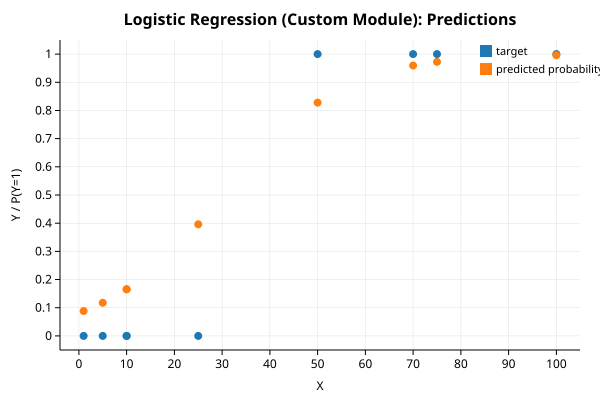

In [17]:
figure({ width: 600, height: 400 })
title('Logistic Regression (Custom Module): Predictions')
xlabel('X')
ylabel('Y / P(Y=1)')
scatter(X, Y, { color: '#1f77b4', label: 'target' })
scatter(X, sigmoid(lastLogits), { color: '#ff7f0e', label: 'predicted probability' })
show()


## Plot: Loss Curve

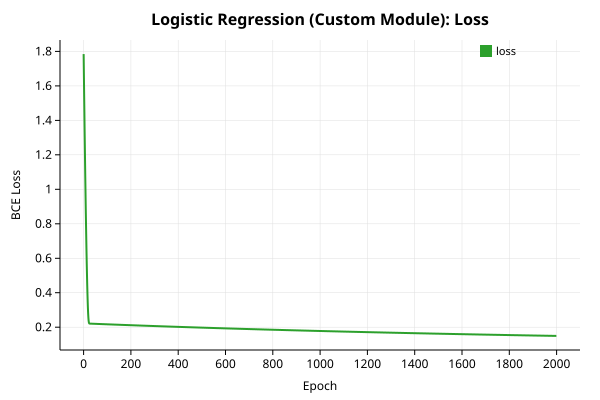

In [18]:
figure({ width: 600, height: 400 })
title('Logistic Regression (Custom Module): Loss')
xlabel('Epoch')
ylabel('BCE Loss')
plot(losses, { label: 'loss', color: '#2ca02c' })
show()

## Recurrent Neural Networks
The remaining sections move from feed-forward models to recurrent ones. 
They show both a hand-built recurrent layer and the built-in recurrent module shapes.


In [19]:
import { tensor, parameter, randn, zeros, add, matmul, tanh, stack, squeeze, clear_grad, grad, sgd } from 'affon:compute'
import nn from 'affon:nn'
import { read } from 'affon:data'
import { writeFileSync } from 'affon:fs'
import type { Tensor } from 'affon:compute'




## Native Shape Ops
Phase 5A tensor ops let us stack hidden states directly without JS array helper functions.


In [20]:
// `stack(rows, 0)` gives [seq, 1, hidden] for row tensors shaped [1, hidden].
// `squeeze(..., 1)` removes the singleton row axis so the hidden sequence is [seq, hidden].


This notebook uses the factory + `compute.module({...})` style. `nn.module_list(...)` lets the stacked example keep array-like submodules without a manual parameter traversal.


In [21]:
const RNNLayer = (embDim: number) => {
  const W = parameter([embDim, embDim]).randn()
  const U = parameter([embDim, embDim]).randn()
  const b = parameter([1, embDim]).zeros()

  return module({ W, U, b }, (state, X: Tensor, h0?: Tensor): Tensor => {
      const seqLen = X.shape[0] as number
      let h = h0 ?? zeros([1, embDim])
      const hList: Tensor[] = []

      for (let i = 0; i < seqLen; i++) {
        const x = X.slice([`${i}:${i + 1}`, ':'])
        h = tanh(add(add(matmul(x, state.W), matmul(h, state.U)), state.b))
        hList.push(h)
      }

      return squeeze(stack(hList, 0), 1)
    }
  })
}

const X = tensor([
  [0.1, 0.2, 0.6],
  [0.2, 0.1, 0.4],
  [0.1, 0.3, 0.3],
  [0.0, 0.7, 0.1],
  [0.5, 0.2, 0.7]
])

const layer = RNNLayer(3)
const H = layer(X)
console.log('H:', H)


Error: TranspileFailed

## Stacked RNN
Multiple layers, each consuming the previous layer’s hidden sequence.


In [ ]:
const RNN = (embDim: number, numLayers: number) => {
  const layers = nn.module_list(numLayers, () => RNNLayer(embDim))
  let hidden_states: Tensor | null = null

  return module({
    layers,
    hidden_states() {
      return hidden_states
    },
  }, (state, X: Tensor): Tensor => {
      let H = X
      // hout includes all layers outputs
      const hout: Tensor[] = []

      for (let i = 0; i < numLayers; i++) {
        H = state.layers[i](H)
        hout.push(H)
      }

      hidden_states = stack(hout, 0)
      return H
    }
  })
}

const model = RNN(3, 2)
const Hout = model(X)


console.log('Hout:', Hout)
console.log('hidden_states:', model.hidden_states())
console.log('parameters', model.parameters.named())


Hout: [5×3 Tensor, dtype=f32]
            0          1          2
  ┌                                  ┐
0 │  0.780179   0.873748  -0.506802  │
1 │  0.545822  -0.182219  -0.980167  │
2 │  0.961056   0.985693  -0.119195  │
3 │  0.955128  -0.202511  -0.996131  │
4 │  0.984523   0.961517  -0.469102  │
  └                                  ┘

hidden_states: [2×5×3 Tensor, dtype=f32]
[[[-0.282723, -0.376667, -0.435442], [0.17012, -0.032407, 0.080819], [-0.229699, -0.260058, -0.316969], [-0.137719, -0.103021, -0.410335], [-0.380352, -0.248213, -0.168209]], [[0.780179, 0.873748, -0.506802], [0.545822, -0.182219, -0.980167], [0.961056, 0.985693, -0.119195], [0.955128, -0.202511, -0.996131], [0.984523, 0.961517, -0.469102]]]

parameters [ [ layers.0.W, [3×3 Tensor, dtype=f32]
             0          1          2
  ┌                                   ┐
0 │  -0.137386   0.289469   -0.13472  │
1 │  -0.523916  -0.252198  -0.909232  │
2 │  -0.286862  -0.624462  -0.452123  │
  └                       

## DataLoader Batching (affon:data)
Use a small CSV dataset and `DataLoader` to iterate sequences in batches.


In [ ]:
const csv = [
  'x0,x1,x2,x3,x4,x5',
  '0.1,0.2,0.6,0.2,0.1,0.4',
  '0.1,0.3,0.3,0.0,0.7,0.1',
  '0.5,0.2,0.7,0.0,0.0,0.0',
  '0.3,0.4,0.6,0.1,0.2,0.4'
].join('\n')

const csvPath = '/tmp/rnn_sequences.csv'
writeFileSync(csvPath, csv)

const dataset = read(csvPath)
const loader = dataset.loader({ batchSize: 2 })

const seqLen = 2
const embDim = 3


const toEmbeddingSeq = (row: number[], seqLen: number, embDim: number): number[][] => {
  const seq: number[][] = []
  for (let t = 0; t < seqLen; t++) {
    seq.push(row.slice(t * embDim, (t + 1) * embDim))
  }
  return seq
}

for (const [batch] of loader) {
  const batchArr = batch.to_array() as number[][]
  const outputs = batchArr.map(row => {
    return model(tensor(toEmbeddingSeq(row, seqLen, embDim)))
  })
  console.log('batch outputs:', outputs)
}


batch outputs: [ [2×3 Tensor, dtype=f32]
            0          1          2
  ┌                                  ┐
0 │  0.780179   0.873748  -0.506802  │
1 │  0.545822  -0.182219  -0.980167  │
  └                                  ┘
, [2×3 Tensor, dtype=f32]
            0        1          2
  ┌                                ┐
0 │  0.718379  0.77115  -0.326215  │
1 │  0.899217  0.34616  -0.976035  │
  └                                ┘
 ]
batch outputs: [ [2×3 Tensor, dtype=f32]
            0          1          2
  ┌                                  ┐
0 │  0.824912   0.880044  -0.437646  │
1 │  0.021554  -0.828005  -0.967924  │
  └                                  ┘
, [2×3 Tensor, dtype=f32]
            0          1          2
  ┌                                  ┐
0 │  0.872782   0.916304  -0.486865  │
1 │  0.654497  -0.249204  -0.986828  │
  └                                  ┘
 ]


## Toy Token Embeddings (Affon-Only)
Affon doesn’t ship a tokenizer, so we simulate embeddings with a tiny vocab and random matrix.


In [ ]:
const vocab = ['[CLS]', 'hello', 'world', '[SEP]']
const vocabIndex = new Map(vocab.map((t, i) => [t, i]))
const embDim = 4

const embeddingTable = randn([vocab.length, embDim])

function oneHot(index: number, size: number): number[] {
  return Array.from({ length: size }, (_, i) => (i === index ? 1 : 0))
}

const tokens = ['hello', 'world']
const oneHotMatrix = tokens.map(t => oneHot(vocabIndex.get(t)!, vocab.length))

// (numTokens x vocab) @ (vocab x embDim) = (numTokens x embDim)
const tokenEmbeddings = matmul(tensor(oneHotMatrix), embeddingTable)

console.log('tokenEmbeddings:', tokenEmbeddings)


tokenEmbeddings: [2×4 Tensor, dtype=f32]
            0          1         2          3
  ┌                                            ┐
0 │  0.068565   1.384415  0.451249   0.103158  │
1 │  0.489123  -0.158917   1.54669  -2.168459  │
  └                                            ┘

